In [2]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from tracking import *
from joblib import Parallel, delayed
import h5py

In [ ]:
fn = "P015_pulsatile_rigid_nobackflow.vtu"
inletfn = "P015_inlet7670.vtu"
savefolder = ""

npoints_desired = 2e6
npoints_inlet = 1e4


In [4]:
# Load data

if fn.split(".")[-1] == "vtu":
    flow = timeMeshSingleVTU(fn)
elif fn.split(".")[-1] == "pvd":
    flow = timeMeshPVD(fn)

In [5]:
# Seed mesh
subsampled = seed_mesh(flow.active_mesh, npoints_desired)
r_init = pv.PolyData(subsampled)

In [6]:
inlet_mesh = pv.read(inletfn)
inlet = seed_region(inlet_mesh, npoints_inlet, inlet_mesh.bounds , normalization=inlet_mesh.point_data.keys()[0])

(np.float64(-6.186769500706551),
 np.float64(5.199900915821028),
 np.float64(-20.37585136235934),
 np.float64(-0.7445359630646384))

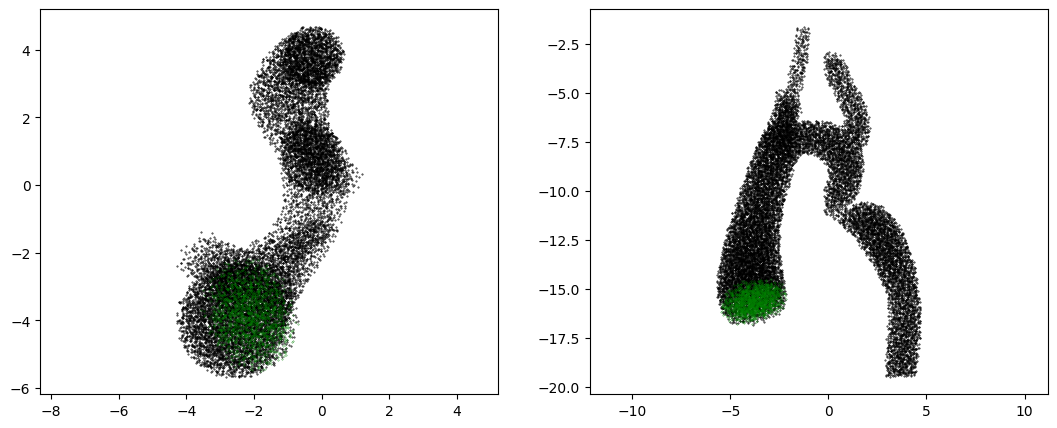

In [ ]:
# Visualize seeding and inlet

nplot = 15000
step = int(subsampled.shape[0] / nplot)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(subsampled[::step, 0], subsampled[::step, 1], "k.", markersize=0.8)
ax[0].plot(inlet[:, 0], inlet[:, 1], "g.", markersize=0.5)
ax[0].axis("equal")

ax[1].plot(subsampled[::step, 1], subsampled[::step, 2], "k.", markersize=0.8)
ax[1].plot(inlet[:, 1], inlet[:, 2], "g.", markersize=0.5)

ax[1].axis("equal")

In [8]:
# Tracking 
dt = 0.0005
tmax = flow.tmax

In [ ]:
n_workers = 10
batch_size = np.ceil(r_init.points.shape[0]/n_workers).astype(int)

batches = batched_particles(r_init.points, batch_size)

results = Parallel(n_jobs=len(batches))(delayed(tracking_parallel)(fn, batch, inlet, dt, tmax, method = "RK4", pbar = (i==0)) for i, batch in enumerate(batches))

r_res = []
m_reset_flag = []
oob_loc_list = [] 

for res in results:
    r_res.append(res[0])
    m_reset_flag.append(res[1])
    oob_loc_list.append(np.concatenate(res[2]))


r_res = np.concatenate(r_res,axis=1)
m_reset_flag = np.concatenate(m_reset_flag,axis=1)
oob_loc_list = np.concatenate(oob_loc_list)

Reading P015_pulsatile_rigid_nobackflow.vtu: 100%|██████████[00:24<00:00]
100%|██████████| 1692/1692 [1:56:12<00:00,  4.12s/it, n_oob=11]


In [24]:
with h5py.File(savefolder + "tracking_2e6_1ms_05solve.h5", "w") as f:
    f.create_dataset("position", data=r_res[::2,:,:])
    f.create_dataset("reset", data=m_reset_flag[::2,:])
    f.create_dataset("dt", data=dt*2)